# State fidelity for a simulated single-qubit $R(\phi,\theta)$ gate

This notebook is meant to serve as an introduction to IonSim by means of state-propagation using an R gate to drive a rotation $\theta$ along an axis $\phi$.

We will:
1. Define a two-level qubit basis (here using `171Yb+` hyperfine sublevels in `S1/2`),
2. Build a driven Hamiltonian corresponding to a single-qubit rotation drive,
3. Propagate an initial state under the time-dependent Schrödinger equation,
4. Graph populations of each qubit state across the dynamical evolution.
5. Estimate state fidelity.

In [ ]:
import numpy as np
import time

import ionsim as sm
from icecream import ic
from typing import Callable

from matplotlib import pyplot as plt

## Define the qubit Hilbert space

We represent one qubit as two internal levels of an ion. IonSim provides an `AtomicStructure`
helper that builds the two-level structure with energies and labels.

`StandardBasis([*spins])` constructs the basis states for the simulation.
For a single qubit, this is typically a two-dimensional Hilbert space with basis states corresponding to the chosen levels.

In [ ]:
spins = [
    sm.AtomicStructure.from_species(
        species="171Yb+",
        term_symbols=["S1/2"],
        level_names=["S1/2,0,0", "S1/2,1,0"],
    )
]

basis = sm.StandardBasis([*spins])
target_spins = [spins[0]]

basis.states

[EnergyEigenstate(components=[LSHyperfineLevel(n=6, j=0.5, term_symbol='S1/2', fine_energy=0.0, hyperfine_A=79437131344.39122, alias=None, l=0, s=0.5, i=0.5, f=np.float64(0.0), mf=np.float64(-0.0), external_energy_shift=0.0, lifetime=None, branching_ratios=None, hyperfine_B=None)]),
 EnergyEigenstate(components=[LSHyperfineLevel(n=6, j=0.5, term_symbol='S1/2', fine_energy=0.0, hyperfine_A=79437131344.39122, alias=None, l=0, s=0.5, i=0.5, f=np.float64(1.0), mf=np.float64(0.0), external_energy_shift=0.0, lifetime=None, branching_ratios=None, hyperfine_B=None)])]

## Drive Hamiltonian for $R(\phi,\theta)$

For a resonant (or near-resonant) single-qubit drive in the interaction picture with the rotating-wave approximation (RWA),
the interaction Hamiltonian can be written (up to conventions) as

$$
H_I(t) = \frac{\Omega}{2}\left(e^{i\phi}\sigma_+ e^{-i\omega t} + e^{-i\phi}\sigma_- e^{+i\omega t}\right),
$$

where:
- $\Omega$ is the Rabi rate (rad/s),
- $\phi$ is the phase of the drive (sets rotation axis in the equatorial plane),
- $\omega$ is the drive frequency.

IonSim expresses this via a `CouplingOperator` built from an off-diagonal matrix element plus a rate/frequency.
The time dependence is then assembled inside `Hamiltonian.hamiltonian_function(t)`.

In [ ]:
def R_hamiltonian(basis: sm.StandardBasis, phi: float, rabi_rate: float, omega: float, sparse: bool = False, mod: Callable = None):
    """
    Build a Hamiltonian describing a single-qubit drive on the target spin.

    Parameters
    ----------
    basis : Basis constructed to represent our system
    phi : Drive phase (rad).
    rabi_rate : Rabi frequency Ω (rad/s).
    omega : Drive frequency (rad/s).
    sparse : Optionally use sparse matrices for computation.
    mod : Optional amplitude modulation function mod(t).
    """
    prefactor = np.exp(1j * phi) * (rabi_rate / 2)

    # σ+ on the full Hilbert space
    raise_target = [basis.enlarge_matrix(sm.Pauli.plus, [spin]) for spin in target_spins]
    operator = prefactor * raise_target[0]

    operators = [
        sm.CouplingOperator.from_matrix(basis, operator, omega, modulation_function=mod),
    ]

    # Cancel bare energies -> interaction frame (H0 ~ 0)
    interaction_frame_energies = [-state.energy for state in basis.states]

    return sm.Hamiltonian(basis, operators, interaction_frame_energies, sparse=sparse)

## Choose pulse parameters

For a square pulse with Rabi rate $\Omega$, the rotation angle is:

$$
\theta = \Omega \tau \quad \Rightarrow \quad \tau = |\theta|/\Omega.
$$

We will test a $\theta=\pi/2$ pulse (a $\sqrt{X}$-like rotation when $\phi=0$).

In [ ]:
sparse = False
amp_mod = None

rabi_rate = 100e3 * 2 * np.pi  # rad/s
detuning = 0.0

# Tune the drive near the qubit frequency omega0
omega0 = target_spins[0].energy_levels[1].energy - target_spins[0].energy_levels[0].energy
omega = omega0 + detuning

phi = 0.0
theta = np.pi / 2
tau = abs(theta) / rabi_rate

## Propagate $|0\rangle$ and compute state fidelity

1. Create an initial state $|0\rangle$ in the chosen basis,
2. Propagate it under the time-dependent Schrödinger equation up to time $\tau$,
3. Compare the final density matrix to the target pure state.

For a pure target state $\rho_{\rm target} = \ket{\psi}\bra{\psi}$, the state fidelity with a simulated state $\rho$ is $F = \text{Tr}[\rho_{\rm target} \rho].$

ic| hamiltonian.hamiltonian_function(0): array([[     0.        +0.j, 314159.26535898+0.j],
                                                [314159.26535898+0.j,      0.        +0.j]])
ic| f"Building Hamiltonian took {end - start} s.": 'Building Hamiltonian took 0.12241509999148548 s.'
ic| f'Evolving wavefunction took {end-start} seconds.': 'Evolving wavefunction took 0.008045899914577603 seconds.'
ic| f"Propagating state took {end - start} s.": 'Propagating state took 0.04794780001975596 s.'
ic| probs[-1, :]: array([0.50000002, 0.49999997])
ic| fidelity: np.float64(0.999999991476443)


Solving ODE with odeintz.


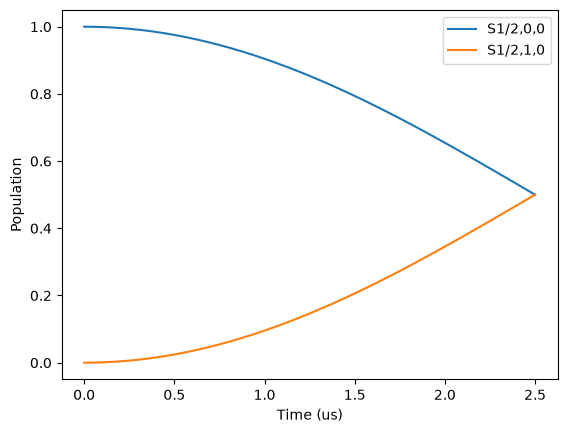

In [ ]:
target_wavefunction = 1 / np.sqrt(2) * np.array([1, -1j])

hamiltonian = R_hamiltonian(basis, phi, rabi_rate, omega, sparse=sparse, mod=amp_mod)

start = time.perf_counter()
ic(hamiltonian.hamiltonian_function(0))
end = time.perf_counter()
ic(f"Building Hamiltonian took {end - start} s.")

# Initialize |0> by coefficients in the computational basis
coefs = [1] + [0] * (len(basis.states)-1)
initial_state = sm.State.from_coefficients(basis, coefs)

# Set times to None to return only the final spin state
num_samples = 41
times = np.linspace(0, tau, num_samples)

start = time.perf_counter()
psis = initial_state.propagate_using_schrodinger_equation(hamiltonian, tau, times)
if times is None:
    # If None is given for the times, only one psi is returned
    psis = [psis]
end = time.perf_counter()
ic(f"Propagating state took {end - start} s.")

# Compute basis populations vs time
probs = np.array([psi.compute_basis_state_probabilities() for psi in psis])
ic(probs[-1, :])

# Fidelity to target state
target_psi = sm.State.from_wavefunction(basis, target_wavefunction)
fidelity = psis[-1].compute_state_fidelity(target_psi.density_matrix)
ic(fidelity)

if times is not None:
    # Plot populations
    for i, state in enumerate(basis.states):
        plt.plot(times*1e6, probs[:, i], label=state.name)

    plt.ylabel("Population")
    plt.xlabel("Time (us)")
    plt.legend()
    plt.show()